In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None) #To see all the columns for a better EDA

In [2]:
# global style for everything

sns.set_theme(style='darkgrid', palette='muted') # can change later 
plt.rcParams.update({ 
    "figure.dpi" : 150,
    "axes.titlesize" : 13,
    "axes.labelsize" : 12,
    "axes.titleweight" : "bold",
})

games =  pd.read_csv('../data/processed/games_clean.csv') # read the cleaned dataset
print(games.shape)

(122610, 34)


In [3]:
games['total_reviews'] = games['positive'] + games['negative'] # get total reviews
games['positive_rate'] = np.where( # get the positive rate of games
    games['total_reviews'] > 0,    # where it has at least 1 reivew
    games['positive'] / games['total_reviews'], 
    np.nan
)

games_reviewed = games[games['total_reviews'] >= 10].copy()
print(f"games with >= 10 reviews: {len(games_reviewed):,} / {len(games):,}")

games with >= 10 reviews: 51,736 / 122,610


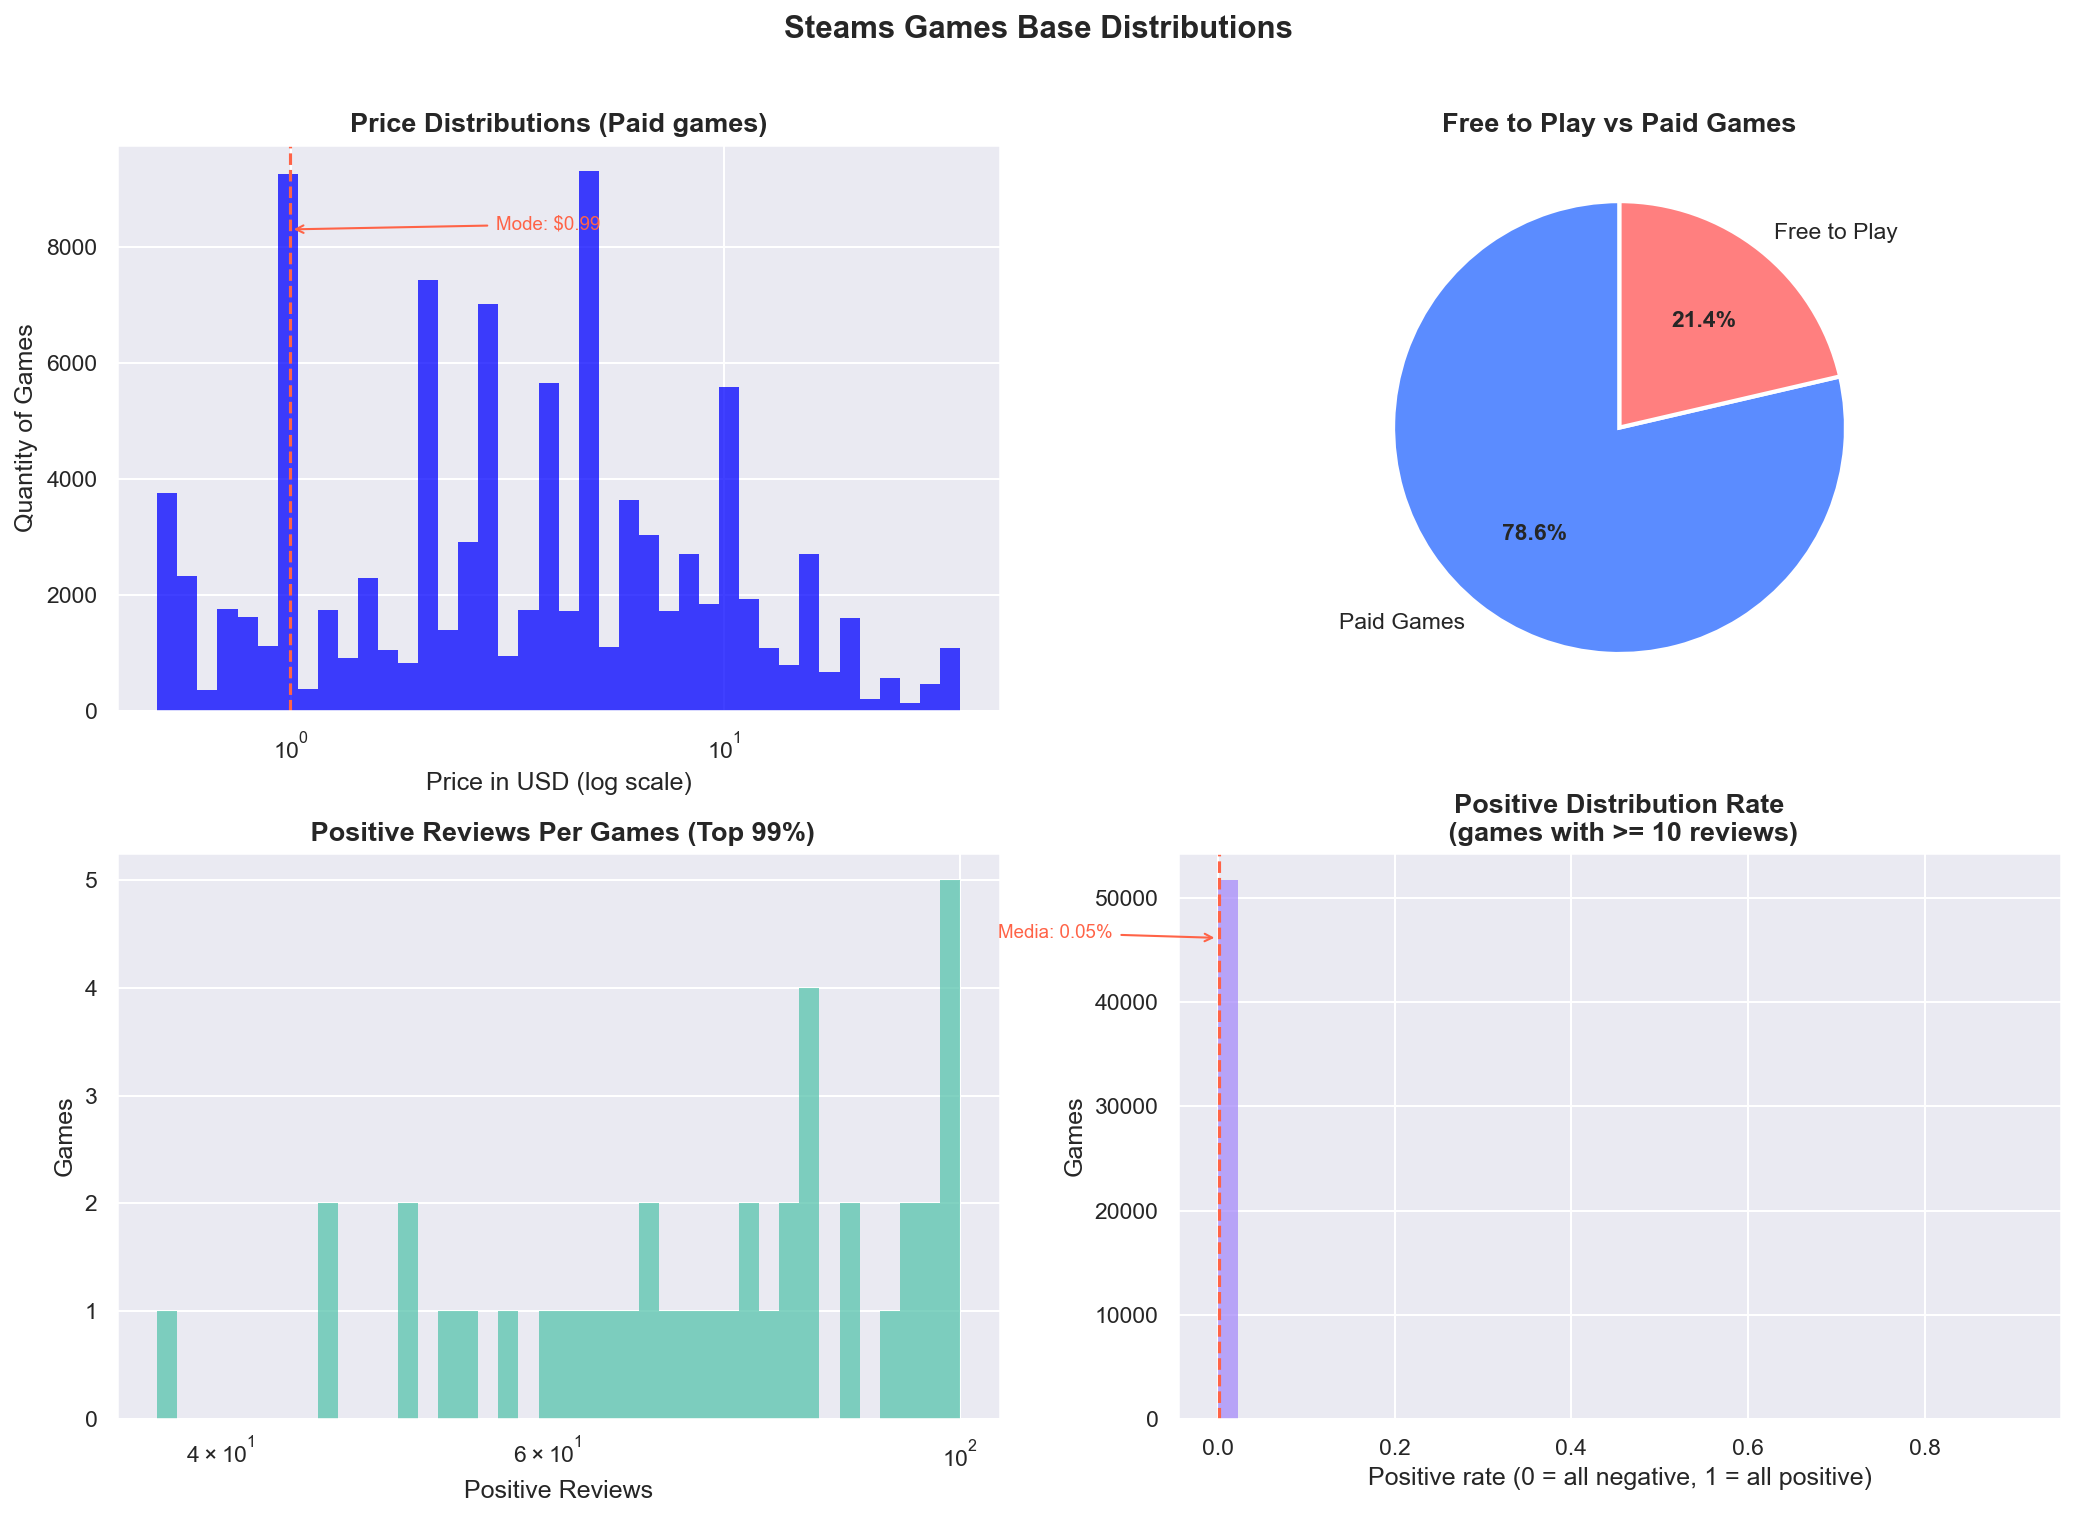

In [25]:
fig, axes = plt.subplots(2,2,
figsize = (14,10))
fig.suptitle("Steams Games Base Distributions", fontsize = 15, fontweight="bold", y=1.01)

ax1 = axes[0,0]
paid = games[games['price'] > 0]['price']
paid = paid.clip(upper = paid.quantile(0.99))
sns.histplot(paid, log_scale = True, bins=40, ax=ax1, color="blue", edgecolor="none")
ax1.set_title("Price Distributions (Paid games)")
ax1.set_xlabel("Price in USD (log scale)")
ax1.set_ylabel("Quantity of Games")

mode_price = paid.mode()[0]
ax1.axvline(mode_price, color="tomato", linestyle="--", linewidth=1.5)
ax1.annotate(f"Mode: ${mode_price:.2f}", xy=(mode_price, ax1.get_ylim()[1]*0.85),
             xytext=(mode_price * 3, ax1.get_ylim()[1]*0.85),
             arrowprops=dict(arrowstyle="->", color="tomato"), color="tomato", fontsize=9)

# ── Plot 2: F2P vs Paid ───────────────────────────────────────────────────────
ax2 = axes[0, 1]
f2p_counts = games['price'].apply(lambda x: 'Free to Play' if x == 0 else 'Paid Games').value_counts()
colors = ["#5B8CFF", "#FF7F7F"]
wedges, texts, autotexts = ax2.pie(
    f2p_counts, labels=f2p_counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight("bold")
ax2.set_title("Free to Play vs Paid Games")

# ── Plot 3: Distribución de reviews positivas (log scale) ────────────────────
ax3 = axes[1, 0]
sns.histplot(
    games_reviewed['positive'], log_scale = True,
    bins=40, ax=ax3, color="#57C4AD", edgecolor="none"
)
ax3.set_title(" Positive Reviews Per Games (Top 99%)")
ax3.set_xlabel("Positive Reviews")
ax3.set_ylabel("Games")

median_pos = games_reviewed['positive'].median()
ax3.axvline(median_pos, color="tomato", linestyle="--", linewidth=1.5)
ax3.annotate(f"Mediana: {int(median_pos):,}", 
             xy=(median_pos, ax3.get_ylim()[1]*0.7),
             xytext=(median_pos * 5, ax3.get_ylim()[1]*0.7),
             arrowprops=dict(arrowstyle="->", color="tomato"), color="tomato", fontsize=9)

# ── Plot 4: Distribución de positive rate ────────────────────────────────────
ax4 = axes[1, 1]
sns.histplot(games_reviewed['positive_rate'], bins=40, ax=ax4, color="#A78BFA", edgecolor="none")
ax4.set_title("Positive Distribution Rate\n (games with >= 10 reviews)")
ax4.set_xlabel("Positive rate (0 = all negative, 1 = all positive)")
ax4.set_ylabel("Games")

mean_rate = games_reviewed['positive_rate'].mean()
ax4.axvline(mean_rate, color="tomato", linestyle="--", linewidth=1.5)
ax4.annotate(f"Media: {mean_rate:.2%}",
             xy=(mean_rate, ax4.get_ylim()[1]*0.85),
             xytext=(mean_rate - 0.25, ax4.get_ylim()[1]*0.85),
             arrowprops=dict(arrowstyle="->", color="tomato"), color="tomato", fontsize=9)

plt.tight_layout()
plt.savefig('../images/01_base_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [14]:
print("games_reviewed shape:", games_reviewed.shape)
print("positive_rate sample:\n", games['positive_rate'].describe())
print("positive sample:\n", games['positive'].describe())
print("price_usd sample:\n", games['price'].describe())

games_reviewed shape: (51736, 36)
positive_rate sample:
 count    80339.000000
mean         0.000303
std          0.014677
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.909091
Name: positive_rate, dtype: float64
positive sample:
 count    122610.000000
mean          0.024549
std           1.394906
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         100.000000
Name: positive, dtype: float64
price_usd sample:
 count    122610.000000
mean          4.765130
std          12.531074
min           0.000000
25%           0.550000
50%           2.240000
75%           5.240000
max         999.980000
Name: price, dtype: float64


In [21]:
# Ver los juegos con más reviews para confirmar
print(games[['name', 'positive', 'negative', 'positive_rate', 'total_reviews']].sort_values('positive', ascending=False).head(10))
print(games_clean[['positive', 'negative']].describe())
# Ver cuántos tienen positive > 1
print("\nJuegos con positive > 1:", (games['positive'] > 1).sum())
print("Juegos con positive == 0:", (games['positive'] == 0).sum())

# Ver el CSV crudo
pd.read_csv('../data/processed/games_clean.csv')[['positive', 'negative']].describe()

                            name  positive  negative  positive_rate  \
51397             Funbag Fantasy       100        21       0.826446   
48514                  K Station       100        10       0.909091   
4646            Hentai IQ Puzzle       100        27       0.787402   
46901          Hentai Strip Shot       100        26       0.793651   
27656   The Tower of Five Hearts       100        16       0.862069   
34479               Meltys Quest        97       446       0.178637   
6658                   Unlock Me        96        35       0.732824   
25482       Ladykiller in a Bind        95       170       0.358491   
21180              Kara no Shojo        94        61       0.606452   
107186             HENTAI PUZZLE        92        22       0.807018   

        total_reviews  
51397             121  
48514             110  
4646              127  
46901             126  
27656             116  
34479             543  
6658              131  
25482             265  
21

NameError: name 'games_clean' is not defined

In [20]:
raw = pd.read_csv('../data/raw/games.csv')

print(raw[['Positive','Negative']].describe() )
print("Max positive raw:", raw['Positive'].max() )

           Positive      Negative
count  1.226110e+05  1.226110e+05
mean   1.044986e+03  1.691974e+02
std    2.809173e+04  5.374645e+03
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00
50%    5.000000e+00  1.000000e+00
75%    3.700000e+01  1.000000e+01
max    7.642084e+06  1.173003e+06
Max positive raw: 7642084
